<a href="https://colab.research.google.com/github/Kigunda-lilian/Data_science/blob/main/lec8_notebook_answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering and Ensemble Learning

**Chapter Introduction**

This notebook accompanies the *Feature Engineering* lecture. It walks through:

1. **Overview of feature engineering** — what it is and why it matters
2. **Transforming numerical variables** — scaling and log transformation
3. **Transforming categorical variables** — label encoding, one-hot encoding, and cross features
4. **Use of domain knowledge** — turning raw data into meaningful features
5. **Ensembling** — bagging, boosting, and the bias-variance tradeoff

A separate session covers model evaluation metrics (MSE, R², precision/recall/F1, ROC-AUC, ...), so those are intentionally not duplicated here.


## 0. Setup

Run the cell below first to import libraries and load the two datasets used throughout the notebook (California Housing for regression, Breast Cancer for classification).


In [ ]:
# Standard libraries
import numpy as np
import numpy.random as random
import pandas as pd
from pandas import Series, DataFrame
import warnings

# Display up to three decimal places
%precision 3

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

# Ignore warnings
warnings.filterwarnings('ignore')

# scikit-learn building blocks used in multiple sections
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import r2_score, accuracy_score


In [ ]:
# Regression task: California Housing
from sklearn.datasets import fetch_california_housing

california_housing = fetch_california_housing(as_frame=True)
X_housing = california_housing.data
y_housing = california_housing.target

# Classification task: Breast Cancer
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
X_cancer = cancer.data
y_cancer = cancer.target

print('California Housing:', X_housing.shape, '/ target:', y_housing.shape)
print('Breast Cancer    :', X_cancer.shape,  '/ target:', y_cancer.shape)


California Housing: (20640, 8) / target: (20640,)
Breast Cancer    : (569, 30) / target: (569,)


#### <Practice Question 1>

Use the California Housing data (`X_housing`, `y_housing` loaded in Section 0) to compare a **linear model** and a **tree-based model** with and without numerical transformations.



In [ ]:
# --- Solution to Practice Question 1 ---
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score


(1) Split the data into train and test with `train_test_split(X_housing, y_housing, test_size=0.2, random_state=0)`.

In [ ]:
# (1) split
X_tr, X_te, y_tr, y_te = train_test_split(X_housing, y_housing, test_size=0.2, random_state=0)

(2) Train two models on the raw features and record their **test R²**:
- `Ridge(alpha=1.0)`
- `DecisionTreeRegressor(random_state=0, max_depth=6)`


In [ ]:
# (2) raw features
ridge_raw = Ridge(alpha=1.0).fit(X_tr, y_tr)
tree_raw  = DecisionTreeRegressor(random_state=0, max_depth=6).fit(X_tr, y_tr)
ridge_raw = r2_score(y_te, ridge_raw.predict(X_te))
tree_raw  = r2_score(y_te, tree_raw.predict(X_te))

(3) Apply `StandardScaler` to the features (fit on train, transform both train and test). Re-train the two models and compare the test R² to part (2). **Which model is affected by scaling, and which is not? Why?** (revisit Section 2.3 if unsure.)

In [ ]:
# (3) standardized
ss = StandardScaler().fit(X_tr)
ridge_std = Ridge(alpha=1.0).fit(ss.transform(X_tr), y_tr)
tree_std  = DecisionTreeRegressor(random_state=0, max_depth=6).fit(ss.transform(X_tr), y_tr)
ridge_std = r2_score(y_te, ridge_std.predict(ss.transform(X_te)))
tree_std  = r2_score(y_te, tree_std.predict(ss.transform(X_te)))


(4) *(Slightly harder)* A quick look at `X_housing.hist(figsize=(12, 8))` shows that `MedInc`, `AveRooms`, `Population`, and `AveOccup` are heavily right-skewed. Apply `np.log1p` to those four columns **in addition to** the standardization from (3), then re-train the two models. Did the linear model improve more than the tree-based model? Explain why in 1–2 sentences.

In [ ]:
# (4) log1p on skewed columns, then standardized
skewed = ['MedInc', 'AveRooms', 'Population', 'AveOccup']
X_tr_log, X_te_log = X_tr.copy(), X_te.copy()
X_tr_log[skewed] = np.log1p(X_tr_log[skewed])
X_te_log[skewed] = np.log1p(X_te_log[skewed])
ss2 = StandardScaler().fit(X_tr_log)
ridge_ls = Ridge(alpha=1.0).fit(ss2.transform(X_tr_log), y_tr)
tree_ls  = DecisionTreeRegressor(random_state=0, max_depth=6).fit(ss2.transform(X_tr_log), y_tr)
ridge_ls = r2_score(y_te, ridge_ls.predict(ss2.transform(X_te_log)))
tree_ls  = r2_score(y_te, tree_ls.predict(ss2.transform(X_te_log)))

pd.DataFrame({
    'Ridge test R²':        [ridge_raw, ridge_std, ridge_ls],
    'DecisionTree test R²': [tree_raw,  tree_std,  tree_ls],
}, index=['(2) raw', '(3) standardized', '(4) log + standardized']).round(3)
# Observation:
# - DecisionTree R² is identical in all three rows — trees split on rank
#   order, so monotonic transforms don't change the model (Section 2.3).
# - Ridge R² is essentially unchanged by standardization alone (with the
#   small alpha=1.0, the regularization is too weak for scale differences
#   to bite). The log transform on the skewed columns gives a small but
#   real lift. With a larger alpha (e.g. Ridge(alpha=100)) scaling would
#   matter too — try it.


,Ridge test R²,DecisionTree test R²
(2) raw,0.594,0.618
(3) standardized,0.594,0.618
(4) log + standardized,0.606,0.618


#### <Practice Question 2>

Re-use the Titanic dataframe `df` loaded in Section 3.2.

(1) Apply both **label encoding** and **one-hot encoding** to the `Embarked` column (fill missing values with `'S'` first). For each encoding, briefly explain which one you would prefer when feeding `Embarked` into (a) a logistic regression, and (b) a decision tree.


In [ ]:
# load Titanic data (Kaggle-style schema) — loaded directly from a public mirror,

TITANIC_URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(TITANIC_URL)


In [ ]:
# --- Solution to Practice Question 2 ---
from sklearn.preprocessing import LabelEncoder

emb = df['Embarked'].fillna('S')

# (1) Embarked: both encodings
emb_label = LabelEncoder().fit_transform(emb)
emb_ohe   = pd.get_dummies(emb, prefix='Embarked').astype(int)


(2) Apply one-hot encoding to the `Sex` column.

In [ ]:
sex_ohe = pd.get_dummies(df['Sex'], prefix='Sex').astype(int)


(3) Create a **cross feature** by combining `Sex` and `Embarked` into a single string label (e.g. `"female_S"`, `"male_C"`, ...), then one-hot encode that combined column.

In [ ]:
# (3) Sex × Embarked cross feature
df['Sex_Embarked'] = df['Sex'] + '_' + emb
sex_emb_ohe = pd.get_dummies(df['Sex_Embarked'], prefix='SexEmb').astype(int)

print('(1) Embarked label (first 6):', emb_label[:6].tolist())
print('    Embarked one-hot columns:', list(emb_ohe.columns))
print('(2) Sex one-hot columns       :', list(sex_ohe.columns))
print('(3) Sex×Embarked one-hot      :', list(sex_emb_ohe.columns))

(1) Embarked label (first 6): [2, 0, 2, 2, 2, 1]
    Embarked one-hot columns: ['Embarked_C', 'Embarked_Q', 'Embarked_S']
(2) Sex one-hot columns       : ['Sex_female', 'Sex_male']
(3) Sex×Embarked one-hot      : ['SexEmb_female_C', 'SexEmb_female_Q', 'SexEmb_female_S', 'SexEmb_male_C', 'SexEmb_male_Q', 'SexEmb_male_S']


In [ ]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,male_S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female_C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female_S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female_S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,male_S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,male_Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,male_S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,male_S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,female_S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,female_C


(4) Compute the survival rate (`Survived` mean) for each `Sex_Embarked` group with `df.groupby('Sex_Embarked')['Survived'].mean()`. Which combination has the highest survival rate, and which has the lowest? Is the gap between them larger than the gap you would get from `Sex` alone or from `Embarked` alone? Use your numbers to justify the answer.

In [ ]:
# (4) Survival rate per Sex × Embarked, then gap comparison
sr = df.groupby('Sex_Embarked')['Survived'].agg(['mean','count']).rename(
    columns={'mean':'survival_rate','count':'n'}
).sort_values('survival_rate', ascending=False)
print()
print('(4) Survival rate per Sex × Embarked:')
print(sr.round(3))

gap_sex   = df.groupby('Sex')['Survived'].mean()
gap_emb   = df.groupby('Embarked')['Survived'].mean()
print()
print(f'Gap by Sex only       : {gap_sex.max() - gap_sex.min():.3f}')
print(f'Gap by Embarked only  : {gap_emb.max() - gap_emb.min():.3f}')
print(f'Gap by Sex × Embarked : {sr["survival_rate"].max() - sr["survival_rate"].min():.3f}')
# Discussion (1): For a logistic regression, prefer one-hot — label encoding
# injects a fake order between the three ports. For a decision tree, label
# encoding is fine because trees split on rank, not magnitude.
# Discussion (4): female_C ≈ 88% (highest) vs male_Q ≈ 7% (lowest) — a gap
# of ~0.80. That is much larger than the Sex-only gap (~0.55) or the
# Embarked-only gap (~0.22) — the cross feature surfaces an interaction
# neither column captures alone.
# Caveat: Q has only ~77 passengers total (41 male_Q), so its rate is less
# statistically stable than C and S — keep an eye on the `n` column.



(4) Survival rate per Sex × Embarked:
              survival_rate    n
Sex_Embarked                    
female_C              0.877   73
female_Q              0.750   36
female_S              0.693  205
male_C                0.305   95
male_S                0.175  441
male_Q                0.073   41

Gap by Sex only       : 0.553
Gap by Embarked only  : 0.217
Gap by Sex × Embarked : 0.804


#### <Practice Question 3>

The Titanic data has two columns describing family composition:

- `SibSp` — number of siblings / spouses aboard
- `Parch` — number of parents / children aboard

Domain knowledge about the disaster suggests that what really mattered was **whether the family could stay together during evacuation**, which depends on the *total* family size rather than the breakdown into siblings vs parents. Use this insight to build new features and inspect them:

(1) Create `FamilySize = SibSp + Parch + 1` (the `+ 1` includes the passenger themselves).

(2) Create a binary `IsAlone` flag that is 1 when `FamilySize == 1` and 0 otherwise.


In [ ]:
# --- Solution to Practice Question 3 ---

# (1)(2) Family-related features
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)


(3) Group by `FamilySize` and compute the mean of `Survived` per group. Plot or print the result.

            survival_rate    n
FamilySize                    
1                   0.304  537
2                   0.553  161
3                   0.578  102
4                   0.724   29
5                   0.200   15
6                   0.136   22
7                   0.333   12
8                   0.000    6
11                  0.000    7


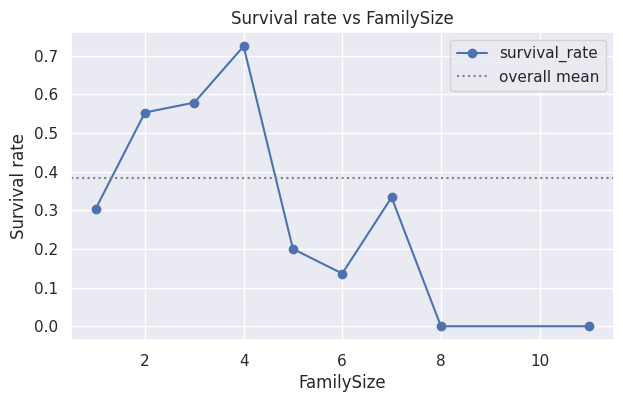

In [ ]:
# (3) Survival rate by FamilySize
sr = df.groupby('FamilySize')['Survived'].agg(['mean','count']).rename(
    columns={'mean':'survival_rate','count':'n'}
)
print(sr.round(3))

sr['survival_rate'].plot(marker='o', figsize=(7, 4))
plt.axhline(df['Survived'].mean(), color='gray', linestyle=':', label='overall mean')
plt.xlabel('FamilySize')
plt.ylabel('Survival rate')
plt.title('Survival rate vs FamilySize')
plt.legend()
plt.show()

(4) **Discuss**: is the relationship between `FamilySize` and survival monotonic, or is there a "sweet spot"? What might explain the pattern you see?

In [ ]:
# (4) Discussion: the pattern is non-monotonic (U/inverted-U shaped).
# - Solo passengers (FamilySize=1): low survival (~30%) — no family helping evacuate.
# - Small families (2-4): peak (~55-72%) — small enough to stick together.
# - Large families (5+): drops sharply (~14-33%) — hard to coordinate during evacuation.


(5) *(Optional)* Train a `LogisticRegression` or `DecisionTreeClassifier` on `Survived` using `[Pclass, Sex (encoded), Age (imputed), Fare]` first, then add `FamilySize` and `IsAlone`. Does the test accuracy improve?

> *Hint:* re-use `df` that was loaded in Section 3.2 — it still contains `SibSp` and `Parch`.


In [ ]:
# (5) Optional: does adding family features improve a logistic-regression baseline?
from sklearn.model_selection import cross_val_score

X_base = pd.concat([
    df[['Pclass', 'Fare']],
    df[['Age']].fillna(df['Age'].median()),
    pd.get_dummies(df['Sex'], drop_first=True).astype(int),
], axis=1)
X_aug = pd.concat([X_base, df[['FamilySize', 'IsAlone']]], axis=1)
y_tt  = df['Survived']

base = cross_val_score(LogisticRegression(max_iter=2000), X_base, y_tt, cv=5).mean()
aug  = cross_val_score(LogisticRegression(max_iter=2000), X_aug,  y_tt, cv=5).mean()
print(f'5-fold CV accuracy without family features: {base:.4f}')
print(f'5-fold CV accuracy with family features:    {aug:.4f}')
# Adding the family features typically lifts CV accuracy by ~1 percentage point.


5-fold CV accuracy without family features: 0.7868
5-fold CV accuracy with family features:    0.7935


Notice the clear non-monotonic pattern:

- **Solo passengers (`FamilySize = 1`)** have a low survival rate (~30%).
- **Small families (2–4)** have the highest survival rate (~55–72%).
- **Large families (5+)** drop back down sharply, presumably because keeping a large group together during the evacuation was harder.

Neither `SibSp` nor `Parch` alone exhibits this U-shape — it only emerges once you sum them. That is the whole point of cross features.


#### <Practice Question 4>

Run the following classifiers on the breast cancer dataset, with and without `BaggingClassifier` (`n_estimators=100`), and report which one benefits most from bagging in your run:

- `LogisticRegression(max_iter=10000)`
- `DecisionTreeClassifier(random_state=0)`
- `KNeighborsClassifier()`


In [ ]:
# --- Solution to Practice Question 4 ---
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier

X_tr, X_te, y_tr, y_te = train_test_split(X_cancer, y_cancer, stratify=y_cancer, random_state=66)

base_models = {
    'LogisticRegression': LogisticRegression(max_iter=10000),
    'DecisionTree':       DecisionTreeClassifier(random_state=0),
    'kNN':                KNeighborsClassifier(),
}

rows = []
for name, base in base_models.items():
    base.fit(X_tr, y_tr)
    base_score = base.score(X_te, y_te)
    bag = BaggingClassifier(base, n_estimators=100, random_state=0).fit(X_tr, y_tr)
    bag_score = bag.score(X_te, y_te)
    rows.append({
        'base model':   name,
        'no bagging':   base_score,
        'bagging x100': bag_score,
        'lift':         bag_score - base_score,
    })

pd.DataFrame(rows).set_index('base model').round(4)
# Observation: the DecisionTree (high-variance baseline) typically benefits
# the most from bagging. LogisticRegression (low-variance baseline) gains
# the least — bagging mostly reduces variance, so there is less for it to
# fix when the base model is already stable. This is the bias-variance
# tradeoff (Section 5.8) showing up empirically.


,no bagging,bagging x100,lift
base model,,,
LogisticRegression,0.9441,0.9441,0.0000
DecisionTree,0.8951,0.9510,0.0559
kNN,0.9231,0.9371,0.0140


#### <Practice Question 5>

Compare a single `DecisionTreeRegressor(max_depth=3)` against `AdaBoostRegressor(DecisionTreeRegressor(max_depth=3), n_estimators=200)` on the California Housing data. Report the train and test R².


In [ ]:
# --- Solution to Practice Question 5 ---
from sklearn.ensemble import AdaBoostRegressor

X_tr, X_te, y_tr, y_te = train_test_split(X_housing, y_housing, random_state=66)

dt = DecisionTreeRegressor(max_depth=3, random_state=0).fit(X_tr, y_tr)
ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3, random_state=0),
    n_estimators=200, random_state=0,
).fit(X_tr, y_tr)

pd.DataFrame({
    'train R²': [dt.score(X_tr, y_tr), ada.score(X_tr, y_tr)],
    'test R²':  [dt.score(X_te, y_te), ada.score(X_te, y_te)],
}, index=['DecisionTree(depth=3)', 'AdaBoost (200 trees)']).round(3)
# Observation: a single depth-3 tree gets test R² ~0.54.
# Surprisingly, AdaBoost(200) here actually does WORSE (~0.44). The reason:
# AdaBoostRegressor's default 'linear' loss is sensitive to outliers in the
# housing data, and at 200 estimators the cumulative correction overshoots.
# Real-world boosting is usually done with GradientBoosting (Section 5.7)
# or XGBoost — those *do* close the bias gap reliably. Try replacing
# `AdaBoostRegressor(...)` with `GradientBoostingRegressor(n_estimators=200,
# max_depth=3, random_state=0)` and you should see test R² jump to ~0.81.


,train R²,test R²
DecisionTree(depth=3),0.531,0.539
AdaBoost (200 trees),0.424,0.442
